In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
data=pd.read_csv("data/housing.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


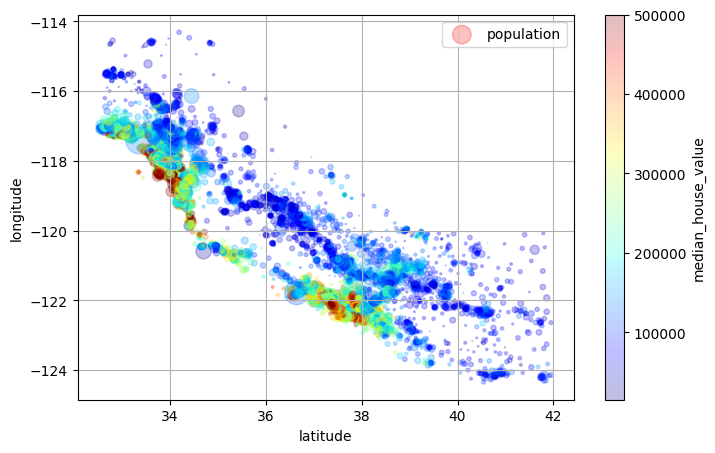

In [13]:
data=data.drop("ocean_proximity",axis=1)
data.plot(kind='scatter',x="latitude",y="longitude",figsize=(8,5),grid=True,alpha=0.25,cmap="jet",colorbar=True,s=data["population"]/100,label="population",c="median_house_value",sharex=False)
plt.savefig("Images/Data.png")

In [14]:
scaler=StandardScaler()
data_Scale=scaler.fit_transform(data)
train,test=train_test_split(data,train_size=.80,shuffle=True,random_state=47)

In [15]:
model=KMeans(n_clusters=15,random_state=47)
pred=model.fit_transform(train[["latitude","longitude"]]).round(2)

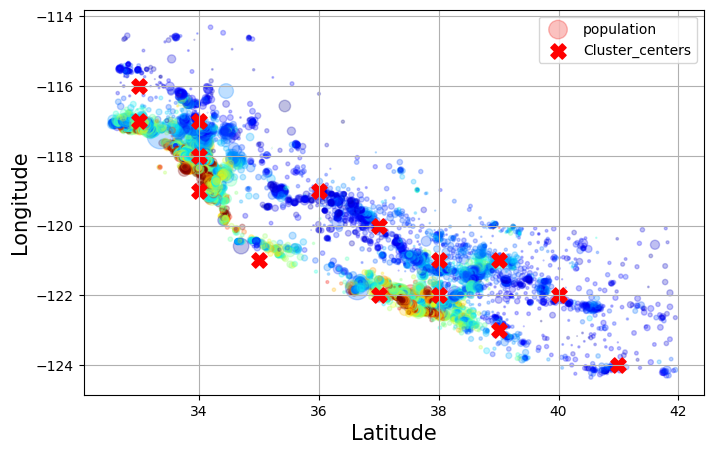

In [16]:
centers=model.cluster_centers_
# print(centers[:1])
data.plot(kind='scatter',x="latitude",y="longitude",grid=True,alpha=0.25,cmap="jet",colorbar=False,figsize=(8,5),s=data["population"]/100,label="population",c="median_house_value",sharex=False)
plt.scatter(centers[:,0].round(0),centers[:,1].round(0),marker='X',s=120,color="red",label="Cluster_centers")
plt.xlabel("Latitude",size=15)
plt.ylabel("Longitude",size=15)
plt.legend()
plt.savefig("Images/Result.png")
plt.show()